/proj/berzelius-2025-315/users/x_dilwi/conda_envs/h5env_clean_py310/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:56: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Image shape after removing channel 5: (7, 2808, 3752)
Clipped image shape: (7, 2808, 3752)


,channel_idx,marker,q50,q99,raw_min,raw_max,clipped_min,clipped_max
0,0,DAPI,1.158466,9.450875,0.0,45.367622,1.158466,9.450875
1,1,CD4,0.000000,4.884495,0.0,40.948463,0.000000,4.884495
2,2,CD20,0.000000,0.227809,0.0,32.525295,0.000000,0.227809
3,3,CD8,0.000000,0.705053,0.0,30.980799,0.000000,0.705053
4,4,FoxP3,0.000000,0.330998,0.0,14.783802,0.000000,0.330997
5,5,PanCK,2.445061,19.210915,0.0,55.241882,2.445061,19.210915
6,6,Autofluorescence,2.377417,7.859890,0.0,27.482933,2.377417,7.859890


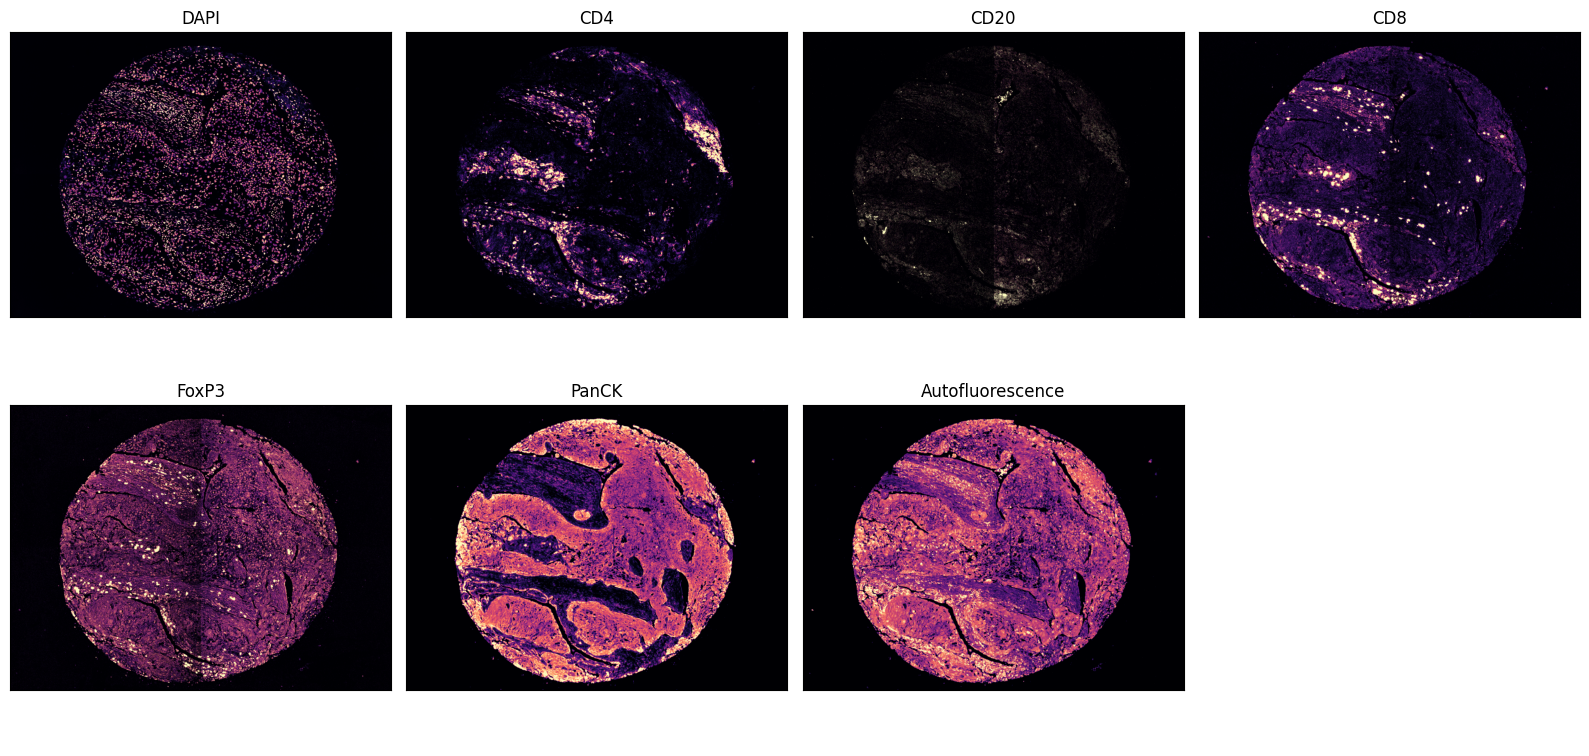

attention_maps_clipped shape: (12, 2808, 3752)


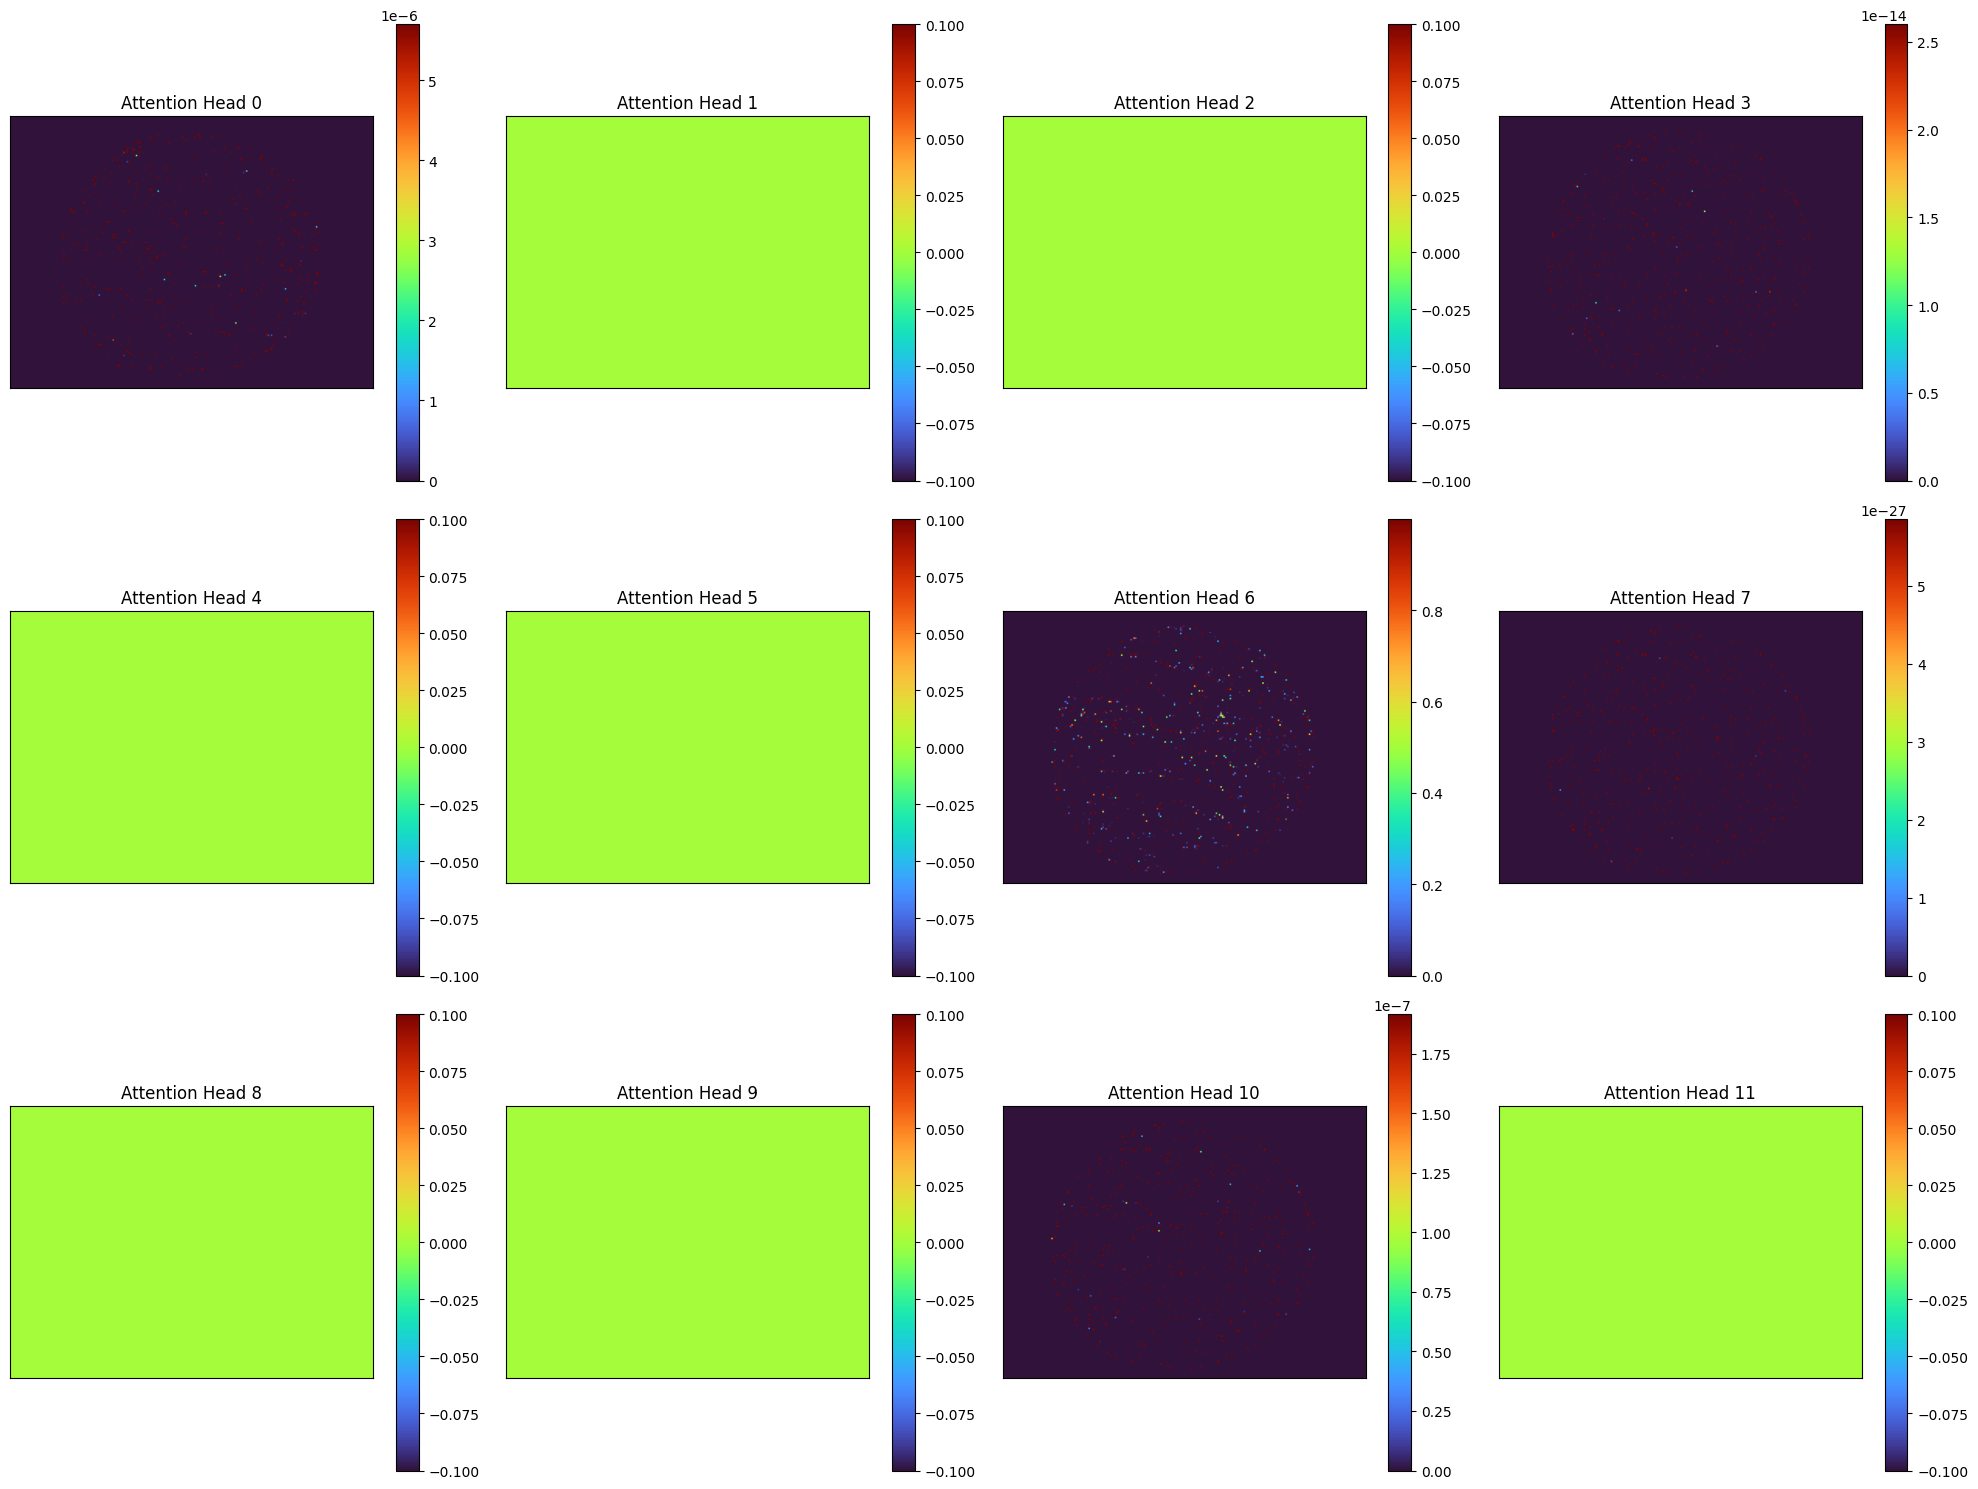

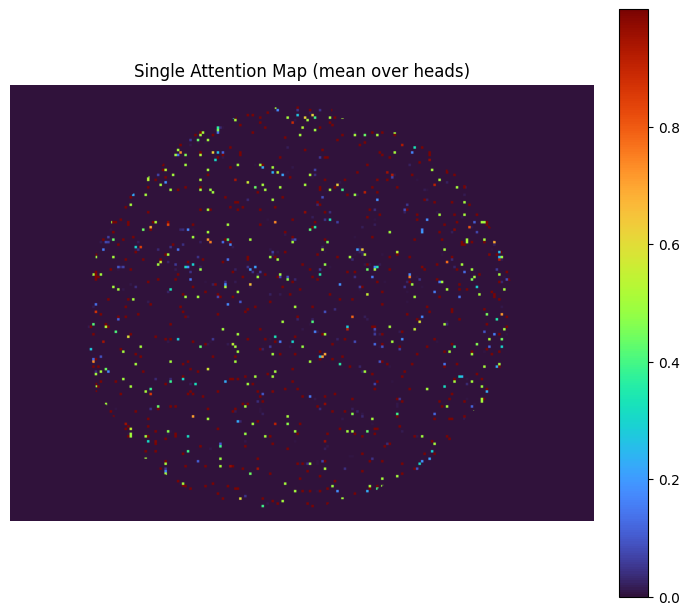

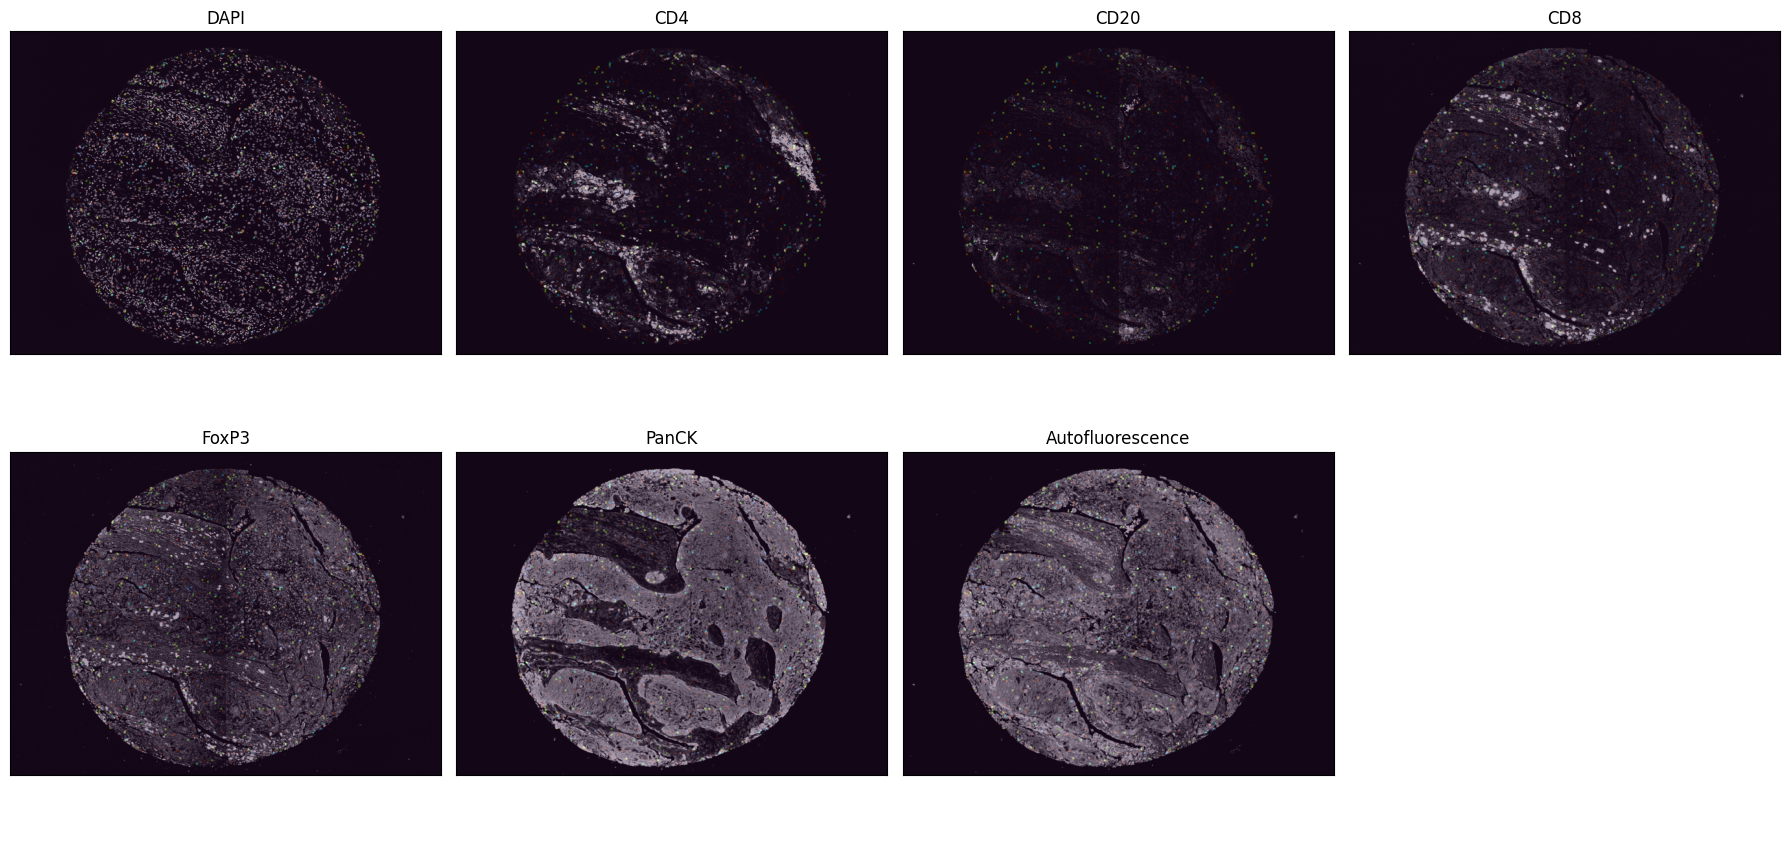

In [1]:
from pathlib import Path
from main import MAE
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from skimage import io

import importlib, attention_map_things
importlib.reload(attention_map_things)

import torch

# ---------------------------------------------------------
# 1) Load model
# ---------------------------------------------------------
model_path = '/proj/berzelius-2025-315/users/x_dilwi/AI-supported-Survival-Prediction-from-Multichannel-Microscopy-Images-of-Cancer-Tissue/Reviewing_copy_rerun/results/MAE_Lightly/epoch-0050.ckpt'
model = MAE.load_from_checkpoint(model_path, map_location='cpu')
model.eval()
backbone = model.backbone.to("cpu")

# ---------------------------------------------------------
# 2) Load TIFF and remove channel 5
# ---------------------------------------------------------
tif_path = "/proj/berzelius-2025-315/users/x_dilwi/full_cores/histodata/TIL/Lung_BOMI2_TIL/output TIFF/BOMI2_TIL_1_Core[1,6,A]_[5234,44107]_component_data.tif"

image = io.imread(tif_path)
image = np.array(image)

# ensure CHW
if image.ndim == 3:
    if image.shape[-1] <= 32 and image.shape[0] > 32:
        image = np.transpose(image, (2, 0, 1))

REMOVE_CH = 5
if image.shape[0] > REMOVE_CH:
    image = np.delete(image, REMOVE_CH, axis=0)
else:
    raise ValueError(f"Expected at least {REMOVE_CH+1} channels, got {image.shape[0]}")

print("Image shape after removing channel 5:", image.shape)

marker_names = ["DAPI","CD4","CD20","CD8","FoxP3","PanCK","Autofluorescence"]

# ---------------------------------------------------------
# 3) Channel-specific clipping
#    This clipped image will be used as MODEL INPUT
# ---------------------------------------------------------
image_clipped = []
clip_stats = []

for i in range(image.shape[0]):
    ch = image[i].astype(np.float32)

    lo = np.quantile(ch, 0.50)   # or use 0.01 if you want less aggressive lower cut
    hi = np.quantile(ch, 0.99)

    ch_clip = np.clip(ch, lo, hi)

    image_clipped.append(ch_clip)
    clip_stats.append({
        "channel_idx": i,
        "marker": marker_names[i],
        "q50": float(lo),
        "q99": float(hi),
        "raw_min": float(ch.min()),
        "raw_max": float(ch.max()),
        "clipped_min": float(ch_clip.min()),
        "clipped_max": float(ch_clip.max()),
    })

image_clipped = np.stack(image_clipped, axis=0)
clip_stats_df = pd.DataFrame(clip_stats)

print("Clipped image shape:", image_clipped.shape)
display(clip_stats_df)

# ---------------------------------------------------------
# 4) Show clipped channels
# ---------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= image_clipped.shape[0]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)
        continue

    ax.imshow(image_clipped[i], cmap='magma')
    ax.set_title(marker_names[i])
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5) Dummy args (same style as your notebook)
# ---------------------------------------------------------
@dataclass
class dummy_dataclass:
    input_size = 224
    overlap = 112
    dataset = 'BOMI'
    data_path = ''

args = dummy_dataclass()

# ---------------------------------------------------------
# 6) Get attention maps from the CLIPPED image
# ---------------------------------------------------------
attention_maps_clipped = attention_map_things.get_attention(image_clipped, backbone, args)

print("attention_maps_clipped shape:", attention_maps_clipped.shape)

# ---------------------------------------------------------
# 7) Plot each attention head
# ---------------------------------------------------------
thattn = []
for attn in attention_maps_clipped:
    quantilecut = np.quantile(attn, 0.7)
    upperquantilecut = np.quantile(attn, 0.99)
    attn = np.clip(attn, a_min=quantilecut, a_max=upperquantilecut)
    thattn.append(attn)

thattn = np.stack(thattn, axis=0)

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
for i, ax in enumerate(axes.flat):
    if i >= thattn.shape[0]:
        ax.axis("off")
        continue

    pp = (thattn[i] - thattn[i].min()) / (thattn[i].max() - thattn[i].min() + 1e-8)
    im = ax.imshow(pp, cmap='turbo')
    ax.set_title(f'Attention Head {i}')
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8) Single attention map from all heads
# ---------------------------------------------------------
eps = 1e-8

head_min = attention_maps_clipped.min(axis=(1, 2), keepdims=True)
head_max = attention_maps_clipped.max(axis=(1, 2), keepdims=True)
attn_norm = (attention_maps_clipped - head_min) / (head_max - head_min + eps)

single_attention_map = attn_norm.mean(axis=0)

q_low, q_high = np.quantile(single_attention_map, [0.70, 0.99])
single_attention_map_vis = np.clip(single_attention_map, q_low, q_high)
single_attention_map_vis = (
    single_attention_map_vis - single_attention_map_vis.min()
) / (single_attention_map_vis.max() - single_attention_map_vis.min() + eps)

plt.figure(figsize=(7, 7))
plt.imshow(single_attention_map_vis, cmap="turbo")
plt.title("Single Attention Map (mean over heads)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9) Overlay single attention map on clipped channels
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    if i >= image_clipped.shape[0]:
        ax.axis("off")
        continue

    ch = image_clipped[i].astype(np.float32)
    ch_vis = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)

    ax.imshow(ch_vis, cmap="gray")
    ax.imshow(single_attention_map_vis, cmap="turbo", alpha=0.40)
    ax.set_title(marker_names[i])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

plt.tight_layout()
plt.show()

image_clipped shape: (7, 2808, 3752)
attention_maps_clipped shape: (12, 2808, 3752)


imagetn shape: (7, 2808, 3752)
thattn shape: (12, 2808, 3752)
single_attention_map shape: (2808, 3752)


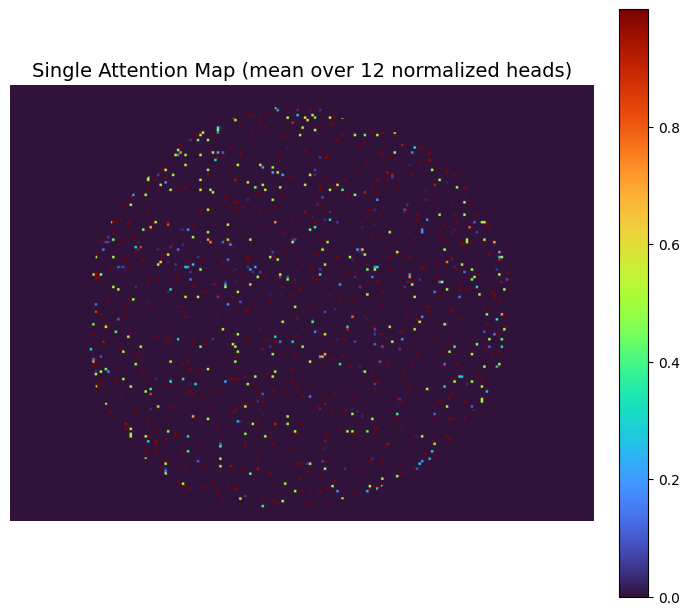

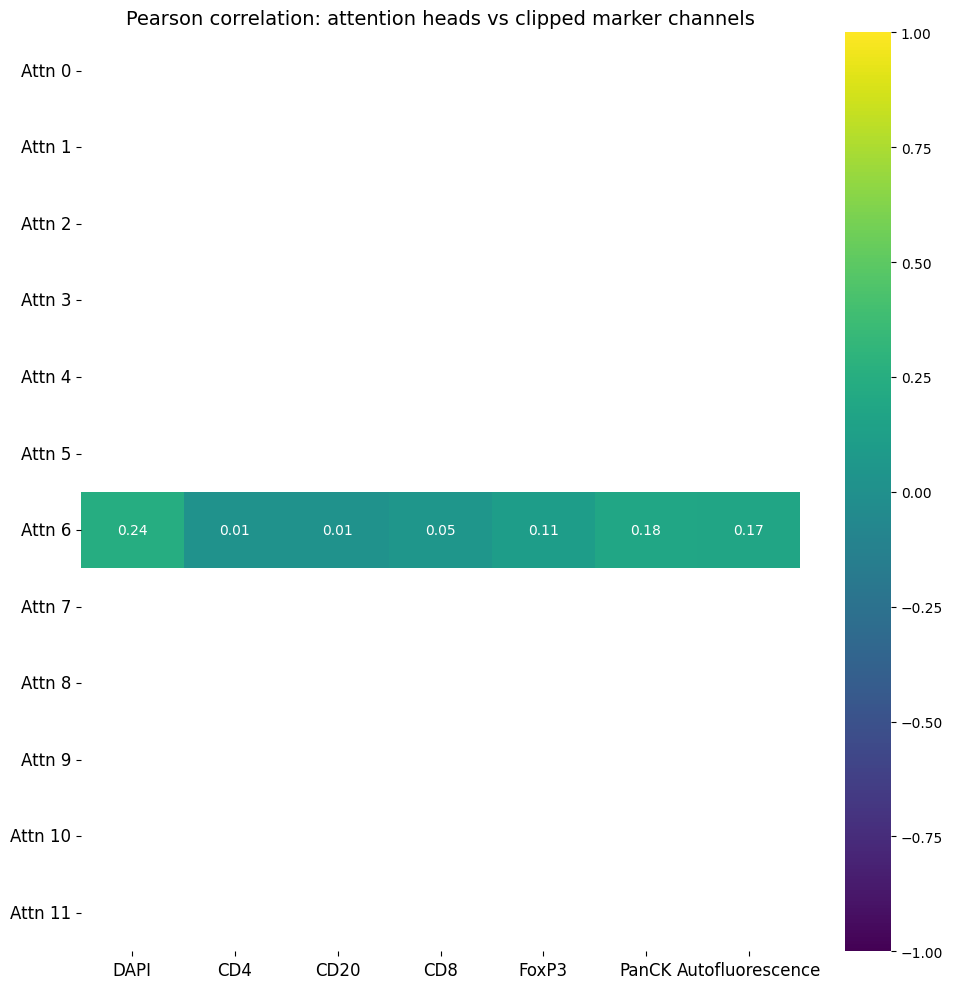

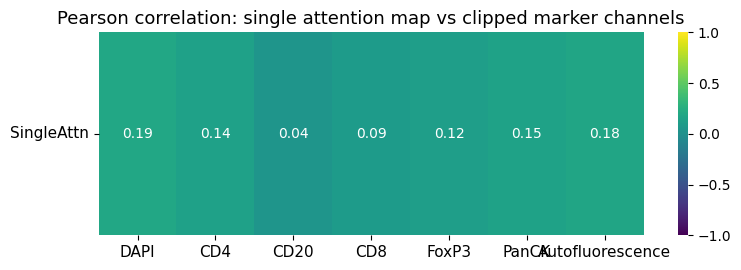

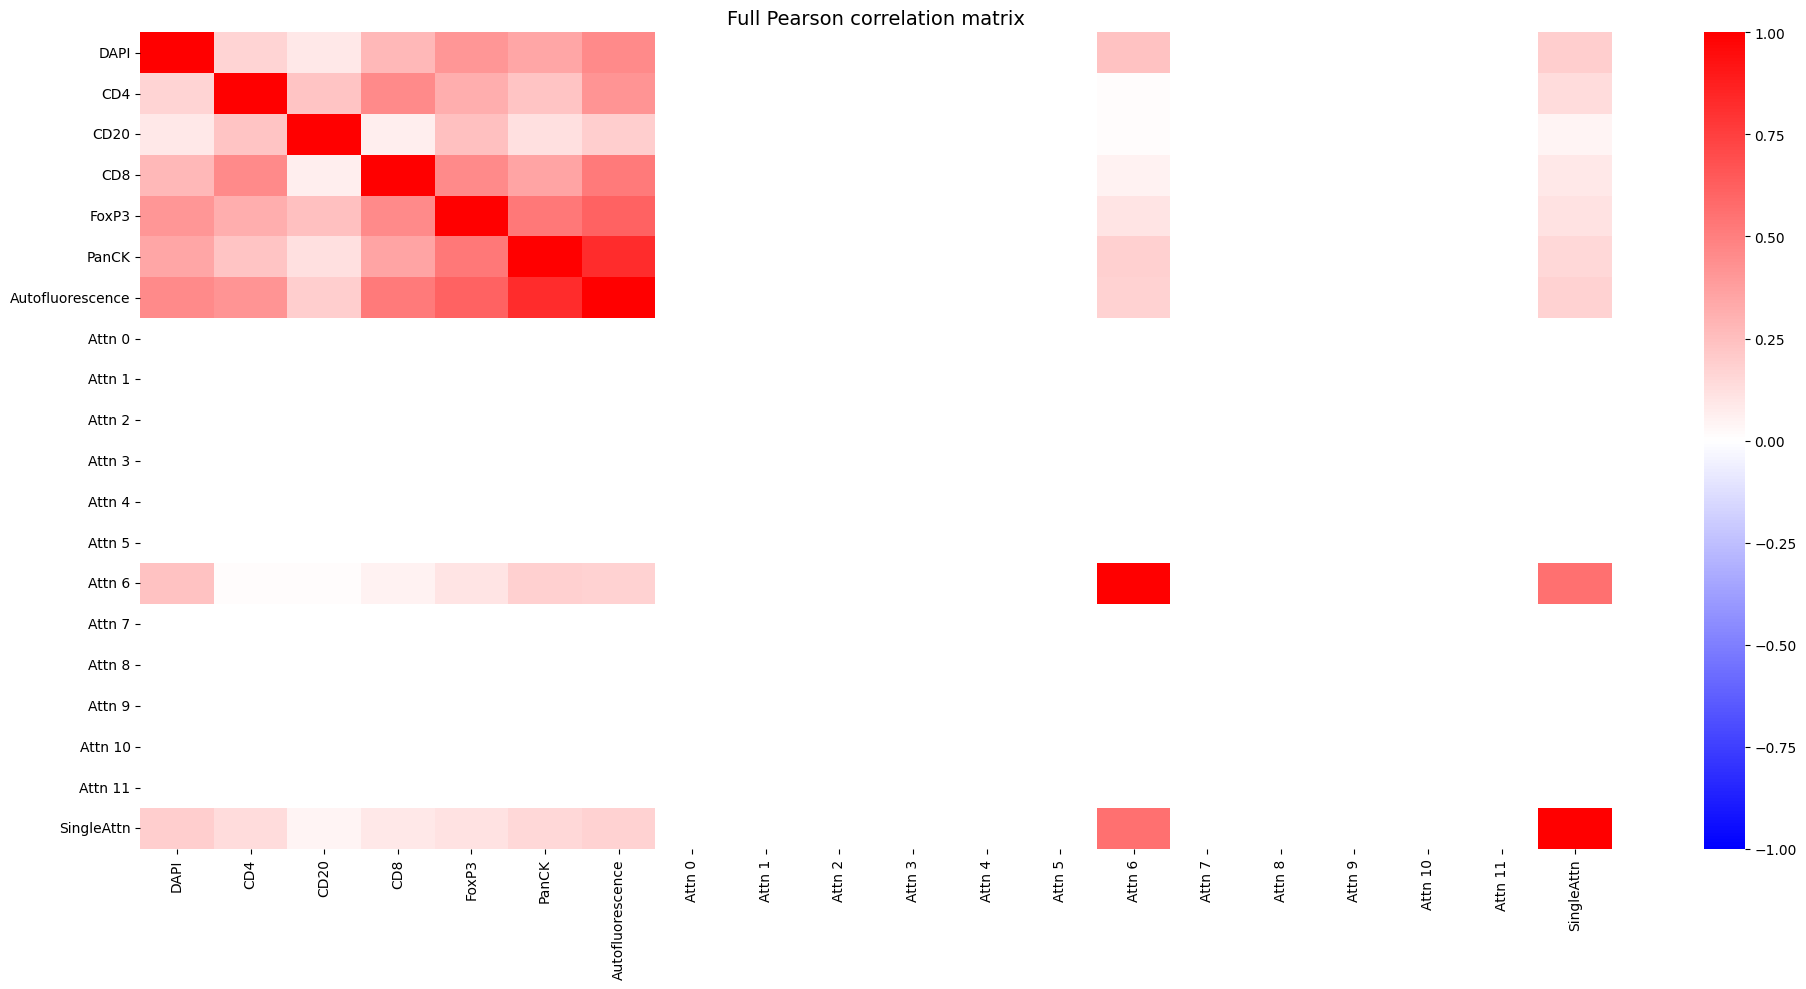

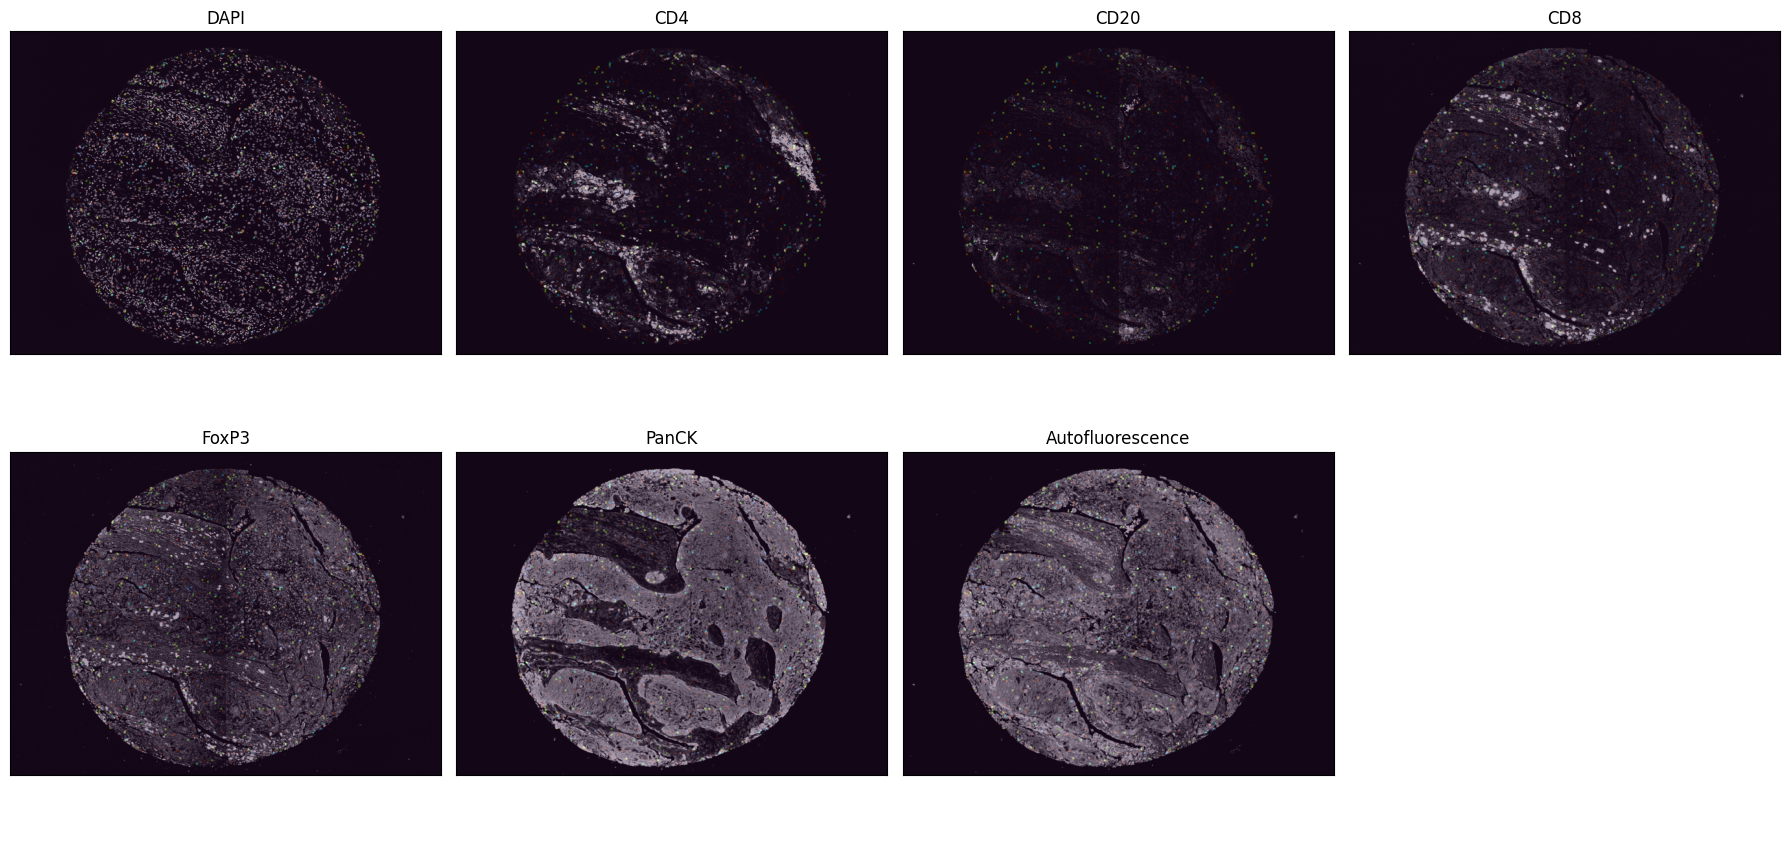

,Marker,Pearson_with_SingleAttn
0,DAPI,0.193368
1,Autofluorescence,0.176028
2,PanCK,0.152183
3,CD4,0.140387
4,FoxP3,0.116214
5,CD8,0.092924
6,CD20,0.043425


In [2]:
# =========================================================
# PEARSON CORRELATION + SINGLE ATTENTION MAP (ALL 12 HEADS)
# Uses:
#   image_clipped            -> shape [7, H, W]
#   attention_maps_clipped   -> shape [12, H, W]
#   marker_names
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

eps = 1e-8

print("image_clipped shape:", image_clipped.shape)
print("attention_maps_clipped shape:", attention_maps_clipped.shape)

# ---------------------------------------------------------
# 1) Prepare clipped image channels for correlation
#    (extra clipping for visualization-style correlation)
# ---------------------------------------------------------
imagetn = []
for ch in image_clipped:
    ch = ch.astype(np.float32)
    lo, hi = np.quantile(ch, [0.50, 0.99])
    ch_clip = np.clip(ch, a_min=lo, a_max=hi)
    imagetn.append(ch_clip)
imagetn = np.stack(imagetn, axis=0)

# ---------------------------------------------------------
# 2) Prepare attention heads for correlation
# ---------------------------------------------------------
thattn = []
for attn in attention_maps_clipped:
    attn = attn.astype(np.float32)
    lo, hi = np.quantile(attn, [0.70, 0.99])
    attn_clip = np.clip(attn, a_min=lo, a_max=hi)
    thattn.append(attn_clip)
thattn = np.stack(thattn, axis=0)

print("imagetn shape:", imagetn.shape)
print("thattn shape:", thattn.shape)

# ---------------------------------------------------------
# 3) Single attention map from all 12 heads
#    Recommended: mean of per-head normalized maps
# ---------------------------------------------------------
head_min = attention_maps_clipped.min(axis=(1, 2), keepdims=True)
head_max = attention_maps_clipped.max(axis=(1, 2), keepdims=True)
attn_norm = (attention_maps_clipped - head_min) / (head_max - head_min + eps)

single_attention_map = attn_norm.mean(axis=0).astype(np.float32)

# For correlation, also clip this map a bit
lo, hi = np.quantile(single_attention_map, [0.70, 0.99])
single_attention_map_corr = np.clip(single_attention_map, a_min=lo, a_max=hi)

# For display
single_attention_map_vis = (single_attention_map_corr - single_attention_map_corr.min()) / (
    single_attention_map_corr.max() - single_attention_map_corr.min() + eps
)

print("single_attention_map shape:", single_attention_map.shape)

# ---------------------------------------------------------
# 4) Plot the single attention map
# ---------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.imshow(single_attention_map_vis, cmap="turbo")
plt.title("Single Attention Map (mean over 12 normalized heads)", fontsize=14)
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5) Robust Pearson correlation helper
#    Avoids crashes if a channel is almost constant
# ---------------------------------------------------------
def safe_corrcoef_matrix(x_np, min_std=1e-12):
    """
    x_np: [N, P]
    returns: [N, N] Pearson correlation matrix with NaN for near-constant rows
    """
    x = np.asarray(x_np, dtype=np.float64)
    means = x.mean(axis=1, keepdims=True)
    stds = x.std(axis=1, keepdims=True)

    valid = (stds[:, 0] > min_std)
    z = np.full_like(x, np.nan, dtype=np.float64)
    z[valid] = (x[valid] - means[valid]) / stds[valid]

    corr = np.full((x.shape[0], x.shape[0]), np.nan, dtype=np.float64)

    for i in range(x.shape[0]):
        for j in range(x.shape[0]):
            if valid[i] and valid[j]:
                corr[i, j] = np.nanmean(z[i] * z[j])

    return corr

# ---------------------------------------------------------
# 6) Pearson correlation: markers vs 12 heads + single map
# ---------------------------------------------------------
all_maps = np.concatenate(
    [
        imagetn.reshape(imagetn.shape[0], -1),
        thattn.reshape(thattn.shape[0], -1),
        single_attention_map_corr[None, ...].reshape(1, -1),
    ],
    axis=0
)

labels = marker_names + [f"Attn {i}" for i in range(thattn.shape[0])] + ["SingleAttn"]

pearsoncorrs = safe_corrcoef_matrix(all_maps)
pearsondf = pd.DataFrame(pearsoncorrs, index=labels, columns=labels)

# ---------------------------------------------------------
# 7) Heatmap: 12 attention heads vs markers
# ---------------------------------------------------------
plt.figure(figsize=(10, 10))
sns.heatmap(
    data=pearsondf.loc[[f"Attn {i}" for i in range(thattn.shape[0])], marker_names],
    cmap="viridis",
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Pearson correlation: attention heads vs clipped marker channels", fontsize=14)
plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8) Heatmap: single attention map vs markers
# ---------------------------------------------------------
plt.figure(figsize=(8, 2.8))
sns.heatmap(
    data=pearsondf.loc[["SingleAttn"], marker_names],
    cmap="viridis",
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Pearson correlation: single attention map vs clipped marker channels", fontsize=13)
plt.xticks(fontsize=11, rotation=0)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9) Optional: full correlation matrix
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))
sns.heatmap(
    data=pearsondf,
    cmap="bwr",
    annot=False,
    vmin=-1,
    vmax=1
)
plt.title("Full Pearson correlation matrix", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10) Optional: overlay single attention map on each clipped marker
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    if i >= image_clipped.shape[0]:
        ax.axis("off")
        continue

    ch = image_clipped[i].astype(np.float32)
    ch_vis = (ch - ch.min()) / (ch.max() - ch.min() + eps)

    ax.imshow(ch_vis, cmap="gray")
    ax.imshow(single_attention_map_vis, cmap="turbo", alpha=0.40)
    ax.set_title(marker_names[i], fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 11) Print the key correlation values in a tidy table
# ---------------------------------------------------------
single_corr_table = pearsondf.loc[["SingleAttn"], marker_names].T.reset_index()
single_corr_table.columns = ["Marker", "Pearson_with_SingleAttn"]
display(single_corr_table.sort_values("Pearson_with_SingleAttn", ascending=False).reset_index(drop=True))

PermissionError: [Errno 13] Permission denied: '/data3'